## 1. Preprocesamiento de Datos
### 1.1 Importar Librerias, carga e inspeccion inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score


In [2]:
df = pd.read_csv("data/dataset_generacion_anual_de_residuos_solidos_domiciliarios_y_municipales.csv", encoding="latin-1", sep=";")
df = df.rename(columns={"GENERACION_DOM URBANA_TANIO": "GENERACION_DOM_URBANA_TANIO"})
df.head()

,FECHA_CORTE,UBIGEO,ANIO,DEPARTAMENTO,PROVINCIA,DISTRITO,REGION_NATURAL,TIPO_MUNICIPALIDAD,POB_TOTAL_INEI,POB_URBANA_INEI,POB_RURAL_INEI,CLASIFICACION_MUNICIPAL_MEF,GENERACION_PER_CAPITA_DOM,GENERACION_DOM_URBANA_TDIA,GENERACION_DOM_URBANA_TANIO,GENERACION_MUN_TANIO,GENERACION_MUN_TDIA,GENERACION_PER_CAPITA_MUNICIPAL
0,18122025,10101,2024,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,SELVA,PROVINCIAL,41335,40358,977,A,0.50,20.18,7365.34,10521.91,28.83,0.71
1,18122025,10102,2024,AMAZONAS,CHACHAPOYAS,ASUNCION,SELVA,DISTRITAL,271,130,141,F,0.53,0.07,25.15,35.93,0.10,0.76
2,18122025,10103,2024,AMAZONAS,CHACHAPOYAS,BALSAS,SIERRA,DISTRITAL,1137,276,861,G,0.45,0.12,45.33,64.76,0.18,0.64
3,18122025,10104,2024,AMAZONAS,CHACHAPOYAS,CHETO,SIERRA,DISTRITAL,713,448,265,F,0.45,0.20,73.58,105.12,0.29,0.64
4,18122025,10105,2024,AMAZONAS,CHACHAPOYAS,CHILIQUIN,SIERRA,DISTRITAL,561,144,417,G,0.45,0.06,23.65,33.79,0.09,0.64


In [3]:
print("Dimensiones del dataset:", df.shape)

print("\nColumnas disponibles:")
print(df.columns.tolist())
print("\n")

df.info()

# Limpieza de texto en columnas categóricas (espacios y mayúsculas inconsistentes)
for col in ["DEPARTAMENTO", "PROVINCIA", "DISTRITO", "REGION_NATURAL", "TIPO_MUNICIPALIDAD"]:
    df[col] = df[col].str.strip().str.upper()

print("Departamentos únicos:", df["DEPARTAMENTO"].nunique())
print(sorted(df["DEPARTAMENTO"].unique()))

Dimensiones del dataset: (11310, 18)

Columnas disponibles:
['FECHA_CORTE', 'UBIGEO', 'ANIO', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'REGION_NATURAL', 'TIPO_MUNICIPALIDAD', 'POB_TOTAL_INEI', 'POB_URBANA_INEI', 'POB_RURAL_INEI', 'CLASIFICACION_MUNICIPAL_MEF', 'GENERACION_PER_CAPITA_DOM', 'GENERACION_DOM_URBANA_TDIA', 'GENERACION_DOM_URBANA_TANIO', 'GENERACION_MUN_TANIO', 'GENERACION_MUN_TDIA', 'GENERACION_PER_CAPITA_MUNICIPAL']


<class 'pandas.DataFrame'>
RangeIndex: 11310 entries, 0 to 11309
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   FECHA_CORTE                      11310 non-null  int64  
 1   UBIGEO                           11310 non-null  int64  
 2   ANIO                             11310 non-null  int64  
 3   DEPARTAMENTO                     11310 non-null  str    
 4   PROVINCIA                        11310 non-null  str    
 5   DISTRITO                    

### 1.2 Tratamiento de valores faltantes
Afortunadamente, este dataset no tiene valores nulos

### 1.3 Deteccion y tratamiento de Outliers (IQR)

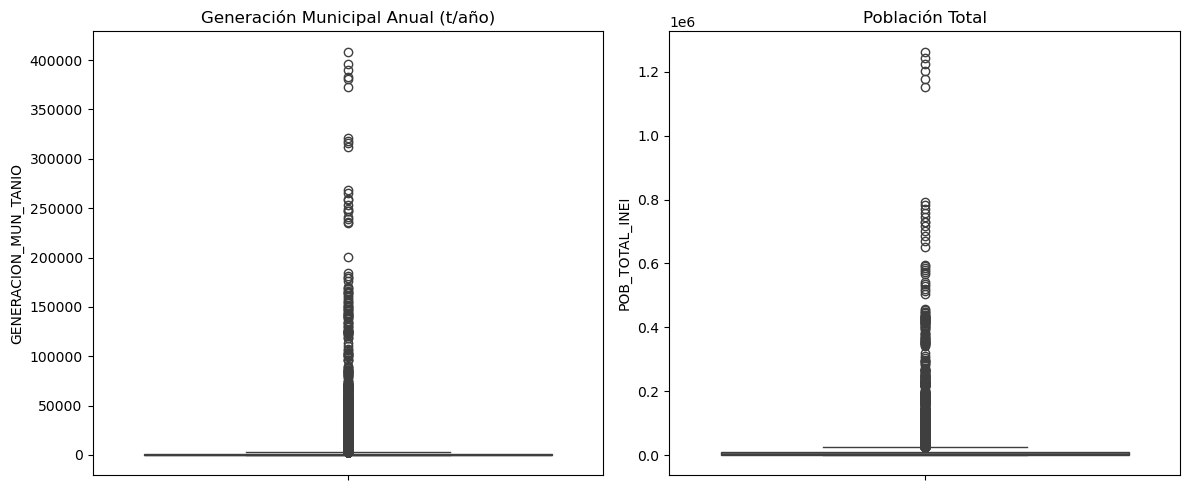

Límites IQR: [-1526.89, 2838.16] toneladas/año
Distritos identificados como outliers: 1880


,DISTRITO,DEPARTAMENTO,GENERACION_MUN_TANIO
1324,SAN JUAN DE LURIGANCHO,LIMA,408652.54
3215,SAN JUAN DE LURIGANCHO,LIMA,396045.05
5105,SAN JUAN DE LURIGANCHO,LIMA,389666.76
6995,SAN JUAN DE LURIGANCHO,LIMA,382679.69
8873,SAN JUAN DE LURIGANCHO,LIMA,380710.63
10747,SAN JUAN DE LURIGANCHO,LIMA,372508.55
5108,SAN MARTIN DE PORRES,LIMA,321502.43
8876,SAN MARTIN DE PORRES,LIMA,318134.52
6998,SAN MARTIN DE PORRES,LIMA,316284.39
10750,SAN MARTIN DE PORRES,LIMA,311814.16


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df["GENERACION_MUN_TANIO"], ax=axes[0])
axes[0].set_title("Generación Municipal Anual (t/año)")
sns.boxplot(y=df["POB_TOTAL_INEI"], ax=axes[1])
axes[1].set_title("Población Total")
plt.tight_layout()
plt.show()

def limites_iqr(serie):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

lim_inf, lim_sup = limites_iqr(df["GENERACION_MUN_TANIO"])
outliers = df[(df["GENERACION_MUN_TANIO"] < lim_inf) | (df["GENERACION_MUN_TANIO"] > lim_sup)]

print(f"Límites IQR: [{lim_inf:.2f}, {lim_sup:.2f}] toneladas/año")
print(f"Distritos identificados como outliers: {len(outliers)}")
outliers[["DISTRITO", "DEPARTAMENTO", "GENERACION_MUN_TANIO"]].sort_values("GENERACION_MUN_TANIO", ascending=False).head(10)

In [5]:
df["ES_OUTLIER_GENERACION"] = (df["GENERACION_MUN_TANIO"] < lim_inf) | (df["GENERACION_MUN_TANIO"] > lim_sup)

# CONFIGURACIÓN DEL EXPERIMENTO
SEPARAR_OUTLIERS_KMEANS = True
# False para comparar que pasa al no separar los outliers del K-Means

if SEPARAR_OUTLIERS_KMEANS:
    df_normal = df[~df["ES_OUTLIER_GENERACION"]].copy()
    df_outliers = df[df["ES_OUTLIER_GENERACION"]].copy()
else:
    df_normal = df.copy()
    df_outliers = df.iloc[0:0].copy()  # vacío, mismas columnas, para que el resto del código no falle

print(f"Modo: {'CON separación' if SEPARAR_OUTLIERS_KMEANS else 'SIN separación'}")
print(f"Distritos para K-Means: {len(df_normal)}")
print(f"Distritos tratados aparte: {len(df_outliers)}")

Modo: CON separación
Distritos para K-Means: 9430
Distritos tratados aparte: 1880


### 1.4 Codificacion de variables categoricas

In [6]:
df_normal_encoded = df_normal.copy()

le_region = LabelEncoder()
df_normal_encoded["REGION_NATURAL_COD"] = le_region.fit_transform(df_normal_encoded["REGION_NATURAL"])

df_normal_encoded = pd.get_dummies(df_normal_encoded, columns=["TIPO_MUNICIPALIDAD", "CLASIFICACION_MUNICIPAL_MEF"], prefix=["TIPO", "MEF"])

df_normal_encoded.head()

,FECHA_CORTE,UBIGEO,ANIO,DEPARTAMENTO,PROVINCIA,DISTRITO,REGION_NATURAL,POB_TOTAL_INEI,POB_URBANA_INEI,POB_RURAL_INEI,...,REGION_NATURAL_COD,TIPO_DISTRITAL,TIPO_PROVINCIAL,MEF_B,MEF_C,MEF_D,MEF_E,MEF_F,MEF_G,MEF_No disponible
1,18122025,10102,2024,AMAZONAS,CHACHAPOYAS,ASUNCION,SELVA,271,130,141,...,2,True,False,False,False,False,False,True,False,False
2,18122025,10103,2024,AMAZONAS,CHACHAPOYAS,BALSAS,SIERRA,1137,276,861,...,3,True,False,False,False,False,False,False,True,False
3,18122025,10104,2024,AMAZONAS,CHACHAPOYAS,CHETO,SIERRA,713,448,265,...,3,True,False,False,False,False,False,True,False,False
4,18122025,10105,2024,AMAZONAS,CHACHAPOYAS,CHILIQUIN,SIERRA,561,144,417,...,3,True,False,False,False,False,False,False,True,False
5,18122025,10106,2024,AMAZONAS,CHACHAPOYAS,CHUQUIBAMBA,SIERRA,1884,437,1447,...,3,True,False,False,False,False,False,False,True,False


**Nota (Jhair)** La categoría MEF "A" no aparece en `df_normal` porque corresponde a las
municipalidades de mayor envergadura (Lima y otras ciudades principales), las cuales
ya fueron separadas como outliers en la etapa de detección de IQR. Esto confirma la
coherencia entre ambos criterios de clasificación.

In [7]:
print("Categorias MEF en df_normal:", sorted(df_normal["CLASIFICACION_MUNICIPAL_MEF"].unique()))
print("Categorias MEF en df_outliers:", sorted(df_outliers["CLASIFICACION_MUNICIPAL_MEF"].unique()))

Categorias MEF en df_normal: ['B', 'C', 'D', 'E', 'F', 'G', 'No disponible']
Categorias MEF en df_outliers: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'No disponible']


### 1.5 Normalizacion

In [8]:
variables_numericas = ["GENERACION_MUN_TANIO", "GENERACION_PER_CAPITA_MUNICIPAL", "POB_TOTAL_INEI"]

scaler = StandardScaler()
df_normal_scaled = df_normal_encoded.copy()
df_normal_scaled[variables_numericas] = scaler.fit_transform(df_normal_encoded[variables_numericas])

df_normal_scaled[variables_numericas].describe()

,GENERACION_MUN_TANIO,GENERACION_PER_CAPITA_MUNICIPAL,POB_TOTAL_INEI
count,9.430000e+03,9.430000e+03,9.430000e+03
mean,-1.205587e-17,1.175447e-16,7.760965e-17
std,1.000053e+00,1.000053e+00,1.000053e+00
min,-7.742959e-01,-3.122966e+00,-9.190228e-01
25%,-6.193133e-01,-1.684583e-01,-6.851849e-01
50%,-4.095958e-01,-1.042299e-01,-3.595678e-01
75%,1.577298e-01,4.095976e-01,3.563917e-01
max,4.249265e+00,1.421871e+01,6.740407e+00


**Nota (Jhair)** 
Esta de abajo es la tabla con valores normalizados redondeados

In [9]:
tabla_normalizacion = df_normal_scaled[variables_numericas].describe().round(2)
tabla_normalizacion

,GENERACION_MUN_TANIO,GENERACION_PER_CAPITA_MUNICIPAL,POB_TOTAL_INEI
count,9430.00,9430.00,9430.00
mean,-0.00,0.00,0.00
std,1.00,1.00,1.00
min,-0.77,-3.12,-0.92
25%,-0.62,-0.17,-0.69
50%,-0.41,-0.10,-0.36
75%,0.16,0.41,0.36
max,4.25,14.22,6.74


## 2. Analisis Exploratorio de Datos (EDA)
### 2.1 Evolucion anual de la generacion municipal por departamento

C:\Users\HP\AppData\Local\Temp\ipykernel_38092\3371358986.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = cm.get_cmap("tab20", len(departamentos))


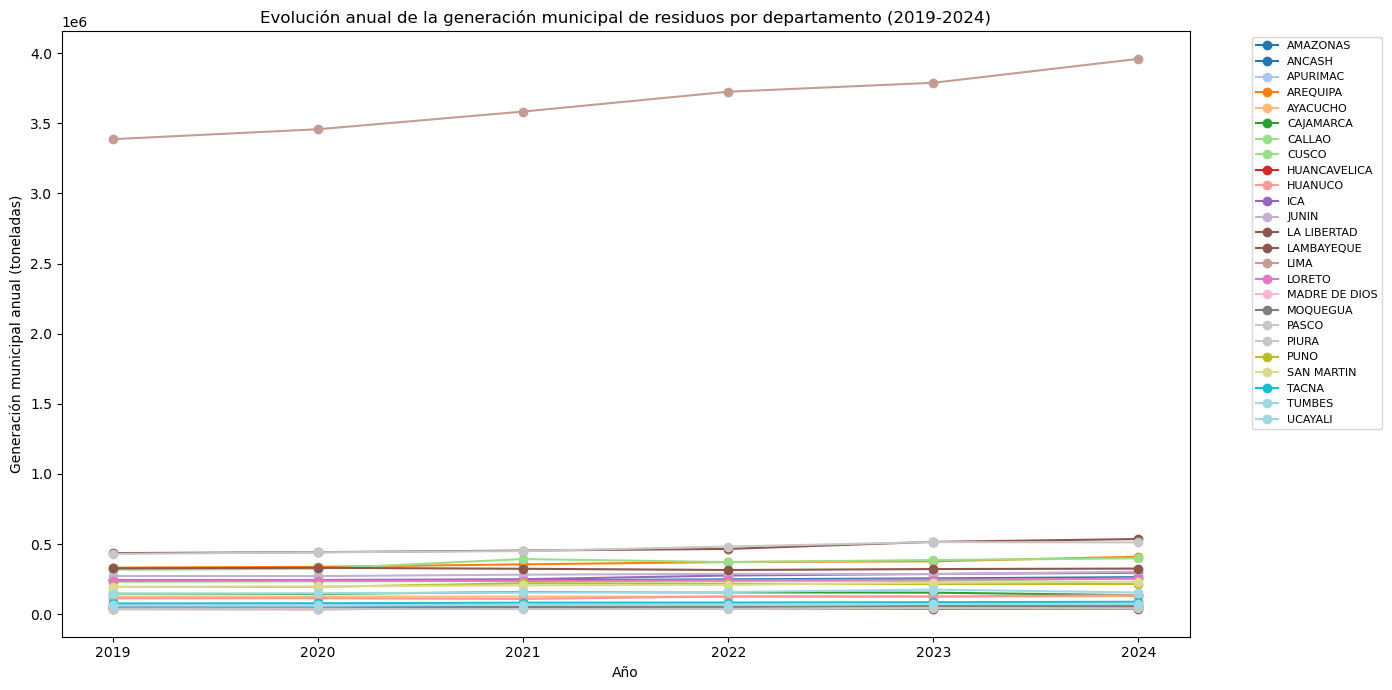

In [10]:
import matplotlib.cm as cm

generacion_anual_depto = df.groupby(["ANIO", "DEPARTAMENTO"])["GENERACION_MUN_TANIO"].sum().reset_index()
departamentos = generacion_anual_depto["DEPARTAMENTO"].unique()
colores = cm.get_cmap("tab20", len(departamentos))

plt.figure(figsize=(14, 7))
for i, depto in enumerate(departamentos):
    datos_depto = generacion_anual_depto[generacion_anual_depto["DEPARTAMENTO"] == depto]
    plt.plot(datos_depto["ANIO"], datos_depto["GENERACION_MUN_TANIO"], marker="o", label=depto, color=colores(i))

plt.title("Evolución anual de la generación municipal de residuos por departamento (2019-2024)")
plt.xlabel("Año")
plt.ylabel("Generación municipal anual (toneladas)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### 2.2 Distribución de la generacion per capita por region natural

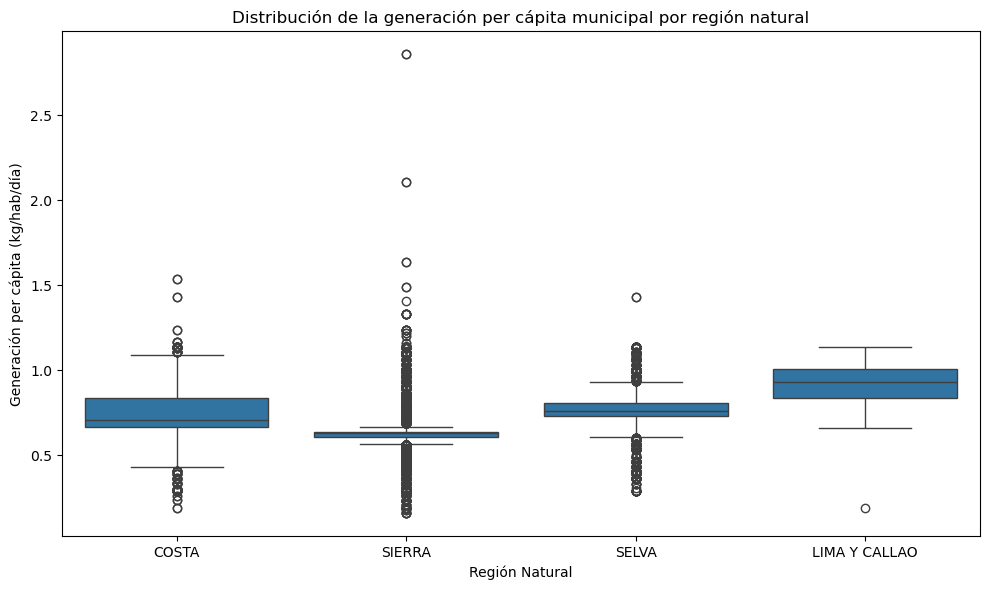

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="REGION_NATURAL", y="GENERACION_PER_CAPITA_MUNICIPAL", order=["COSTA", "SIERRA", "SELVA", "LIMA Y CALLAO"])
plt.title("Distribución de la generación per cápita municipal por región natural")
plt.xlabel("Región Natural")
plt.ylabel("Generación per cápita (kg/hab/día)")
plt.tight_layout()
plt.show()

### 2.3 Mapa de calor de correlaciones

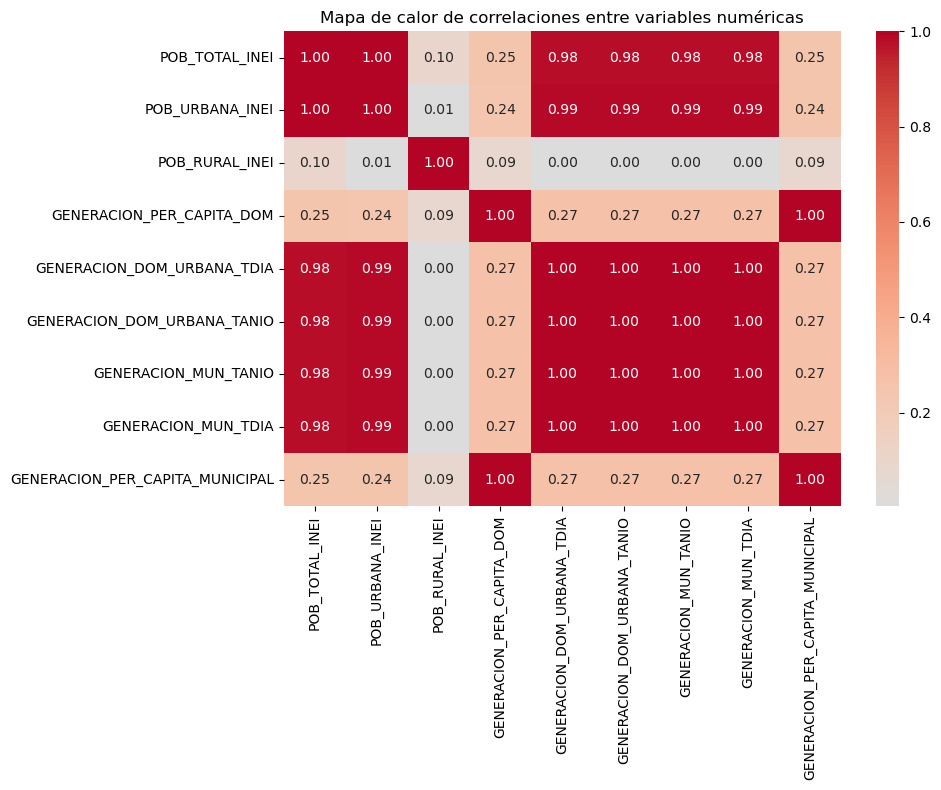

In [12]:
variables_correlacion = ["POB_TOTAL_INEI", "POB_URBANA_INEI", "POB_RURAL_INEI", 
                           "GENERACION_PER_CAPITA_DOM", "GENERACION_DOM_URBANA_TDIA",
                           "GENERACION_DOM_URBANA_TANIO", "GENERACION_MUN_TANIO", 
                           "GENERACION_MUN_TDIA", "GENERACION_PER_CAPITA_MUNICIPAL"]

matriz_corr = df[variables_correlacion].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Mapa de calor de correlaciones entre variables numéricas")
plt.tight_layout()
plt.show()

### 2.4 Histogramas de distribucion (asimetria y normalidad)

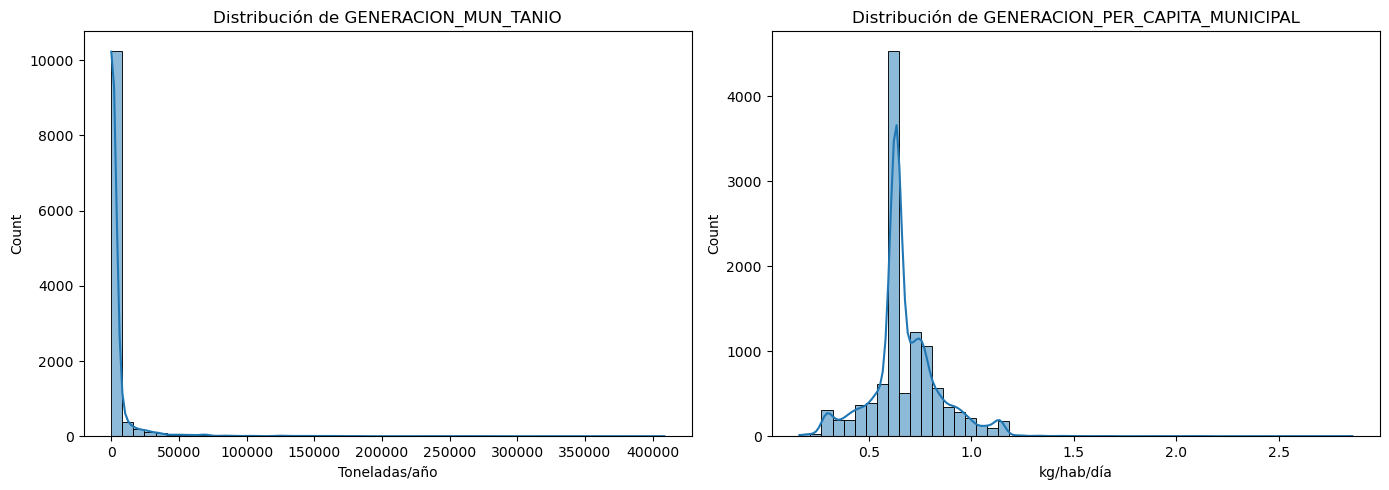

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["GENERACION_MUN_TANIO"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribución de GENERACION_MUN_TANIO")
axes[0].set_xlabel("Toneladas/año")

sns.histplot(df["GENERACION_PER_CAPITA_MUNICIPAL"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Distribución de GENERACION_PER_CAPITA_MUNICIPAL")
axes[1].set_xlabel("kg/hab/día")

plt.tight_layout()
plt.show()

### 2.5 Gráficos de barras: generación por tipo de municipalidad y clasificación MEF

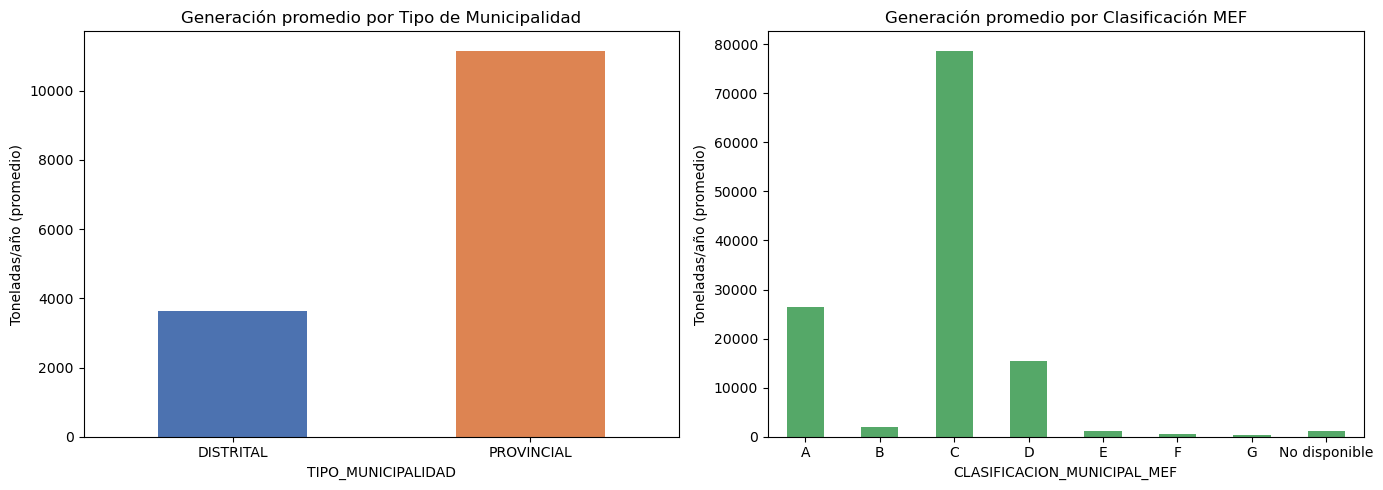

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby("TIPO_MUNICIPALIDAD")["GENERACION_MUN_TANIO"].mean().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Generación promedio por Tipo de Municipalidad")
axes[0].set_ylabel("Toneladas/año (promedio)")
axes[0].tick_params(axis="x", rotation=0)

orden_mef = ["A", "B", "C", "D", "E", "F", "G", "No disponible"]
df.groupby("CLASIFICACION_MUNICIPAL_MEF")["GENERACION_MUN_TANIO"].mean().reindex(orden_mef).plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Generación promedio por Clasificación MEF")
axes[1].set_ylabel("Toneladas/año (promedio)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 3. Clustering
### 3.1. Preparación de datos 

In [15]:
X_cluster = df_normal_scaled[['POB_TOTAL_INEI', 'GENERACION_MUN_TANIO', 'GENERACION_PER_CAPITA_MUNICIPAL']]

### 3.2 Método del Codo para K-Means

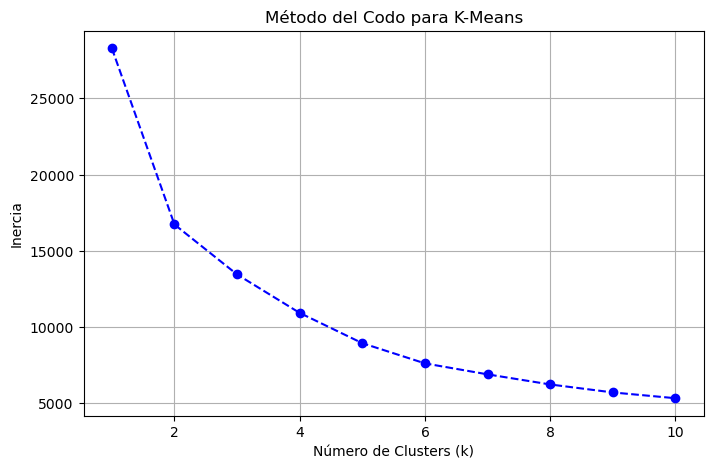

In [16]:
inercia = []
rango_k = range(1, 11)
for k in rango_k:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_cluster)
    inercia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercia, marker='o', linestyle='--', color='b')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

### 3.2.1 Validación con Coeficiente de Silueta

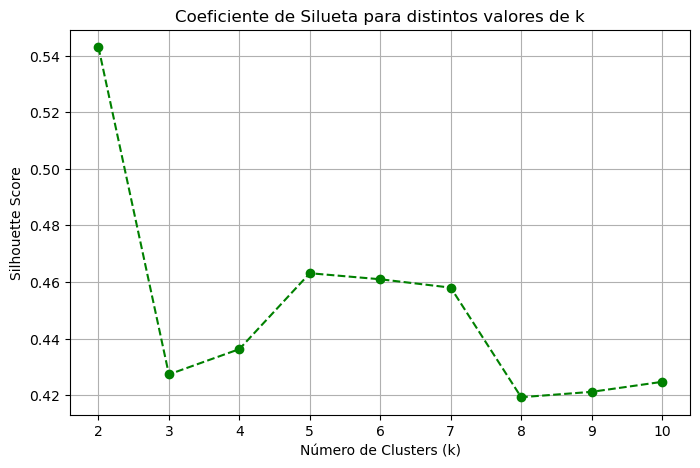

Silhouette scores por k: [0.543, 0.427, 0.436, 0.463, 0.461, 0.458, 0.419, 0.421, 0.425]
k con mayor silhouette score: 2 (score=0.543)
k elegido segun metodo del codo: 3 (score=0.427)


In [17]:
silhouette_scores = []
rango_k_sil = range(2, 11)
for k in rango_k_sil:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels_temp)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(list(rango_k_sil), silhouette_scores, marker='o', linestyle='--', color='green')
plt.title('Coeficiente de Silueta para distintos valores de k')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

mejor_k = list(rango_k_sil)[silhouette_scores.index(max(silhouette_scores))]
print(f"Silhouette scores por k: {[round(s,3) for s in silhouette_scores]}")
print(f"k con mayor silhouette score: {mejor_k} (score={max(silhouette_scores):.3f})")
print(f"k elegido segun metodo del codo: 3 (score={silhouette_scores[list(rango_k_sil).index(3)]:.3f})")

**Nota:** El coeficiente de silueta indica que k=2 produce clusters ligeramente
más compactos (0.543) que k=3 (con 0.427). Sin embargo, mantengo k=3 porque
el objetivo del proyecto es clasificar distritos en tres niveles de criticidad
(ya sea baja media o alta), lo cual ofrece mayor utilidad práctica para la toma de
decisiones municipales que una segmentación binaria, aun con una cohesión
interna ligeramente menor.

### 3.3 Ejecución del algoritmo K-Means (k=3)

In [18]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df_normal['CLUSTER_CRITICIDAD'] = kmeans.fit_predict(X_cluster)

### 3.4 Visualización de los Distritos Agrupados

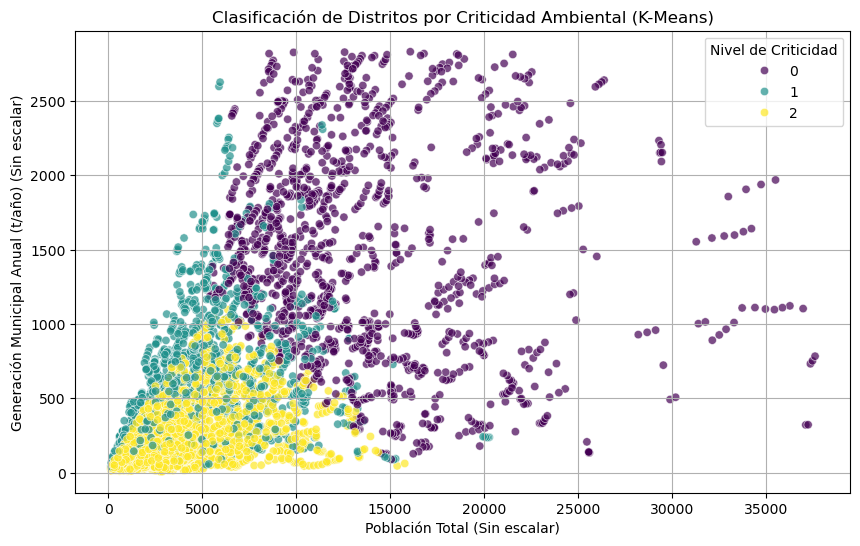

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_normal['POB_TOTAL_INEI'],
    y=df_normal['GENERACION_MUN_TANIO'],
    hue=df_normal['CLUSTER_CRITICIDAD'],
    palette='viridis',
    alpha=0.7
)
plt.title('Clasificación de Distritos por Criticidad Ambiental (K-Means)')
plt.xlabel('Población Total (Sin escalar)')
plt.ylabel('Generación Municipal Anual (t/año) (Sin escalar)')
plt.legend(title='Nivel de Criticidad')
plt.grid(True)
plt.show()

### 3.5 Interpretación de Clusters y Reincorporación de Outliers

In [20]:
resumen_clusters = df_normal.groupby('CLUSTER_CRITICIDAD')[
    ['GENERACION_MUN_TANIO', 'GENERACION_PER_CAPITA_MUNICIPAL', 'POB_TOTAL_INEI']
].mean().round(2)
resumen_clusters

,GENERACION_MUN_TANIO,GENERACION_PER_CAPITA_MUNICIPAL,POB_TOTAL_INEI
CLUSTER_CRITICIDAD,,,
0,1475.96,0.66,13563.91
1,608.03,0.85,4766.32
2,191.51,0.59,2759.13


**Nota:** Los clusters se ordenan según su GENERACION_MUN_TANIO promedio (y de menor a
mayor) y se etiquetan como con Baja, Media y Alta criticidad. Los distritos identificados
como outliers se reincorporan al dataset final
asignándoles directamente la etiqueta Alta, como definimos en preprocesamiento.

In [21]:
orden_clusters = resumen_clusters['GENERACION_MUN_TANIO'].sort_values().index.tolist()
etiquetas_criticidad = ['Baja', 'Media', 'Alta']
mapa_criticidad = dict(zip(orden_clusters, etiquetas_criticidad))
print("Mapeo cluster -> criticidad:", mapa_criticidad)

df_normal['CRITICIDAD'] = df_normal['CLUSTER_CRITICIDAD'].map(mapa_criticidad)
df_outliers['CRITICIDAD'] = 'Alta'
df_outliers['CLUSTER_CRITICIDAD'] = -1  # Marca: clasificado directamente (no por K-Means)

df_clasificado = pd.concat([df_normal, df_outliers], ignore_index=True)

print(f"\nTotal de distritos clasificados: {len(df_clasificado)}")
print(df_clasificado['CRITICIDAD'].value_counts())

Mapeo cluster -> criticidad: {2: 'Baja', 1: 'Media', 0: 'Alta'}

Total de distritos clasificados: 11310
CRITICIDAD
Baja     6549
Alta     3212
Media    1549
Name: count, dtype: int64


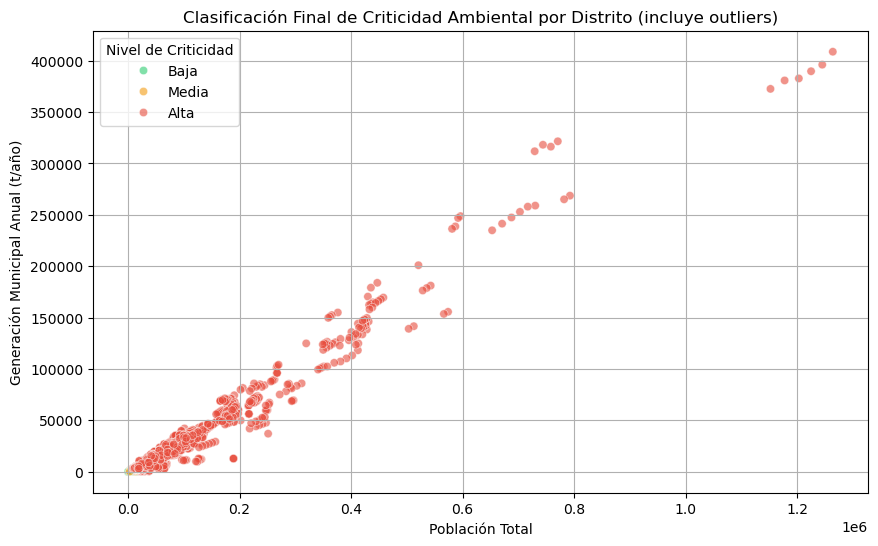

In [22]:
plt.figure(figsize=(10, 6))
orden_leyenda = ['Baja', 'Media', 'Alta']
sns.scatterplot(
    data=df_clasificado,
    x='POB_TOTAL_INEI',
    y='GENERACION_MUN_TANIO',
    hue='CRITICIDAD',
    hue_order=orden_leyenda,
    palette={'Baja': '#2ecc71', 'Media': '#f39c12', 'Alta': '#e74c3c'},
    alpha=0.6
)
plt.title('Clasificación Final de Criticidad Ambiental por Distrito (incluye outliers)')
plt.xlabel('Población Total')
plt.ylabel('Generación Municipal Anual (t/año)')
plt.legend(title='Nivel de Criticidad')
plt.grid(True)
plt.show()

In [23]:
df_clasificado[['DISTRITO', 'DEPARTAMENTO', 'POB_TOTAL_INEI', 'GENERACION_MUN_TANIO', 'CRITICIDAD']]\
    .sort_values('GENERACION_MUN_TANIO', ascending=False).head(15)

,DISTRITO,DEPARTAMENTO,POB_TOTAL_INEI,GENERACION_MUN_TANIO,CRITICIDAD
9635,SAN JUAN DE LURIGANCHO,LIMA,1264060,408652.54,Alta
9954,SAN JUAN DE LURIGANCHO,LIMA,1245145,396045.05,Alta
10269,SAN JUAN DE LURIGANCHO,LIMA,1225092,389666.76,Alta
10578,SAN JUAN DE LURIGANCHO,LIMA,1203125,382679.69,Alta
10886,SAN JUAN DE LURIGANCHO,LIMA,1177629,380710.63,Alta
11197,SAN JUAN DE LURIGANCHO,LIMA,1152258,372508.55,Alta
10272,SAN MARTIN DE PORRES,LIMA,770725,321502.43,Alta
10889,SAN MARTIN DE PORRES,LIMA,744050,318134.52,Alta
10581,SAN MARTIN DE PORRES,LIMA,758216,316284.39,Alta
11200,SAN MARTIN DE PORRES,LIMA,729268,311814.16,Alta


## 4. Predicción 
### 4.1 Preparación de la serie temporal por departamento

In [24]:
generacion_depto_anio = df.groupby(['DEPARTAMENTO', 'ANIO'])['GENERACION_MUN_TANIO'].sum().reset_index()
generacion_depto_anio.head()

,DEPARTAMENTO,ANIO,GENERACION_MUN_TANIO
0,AMAZONAS,2019,57229.72
1,AMAZONAS,2020,56528.40
2,AMAZONAS,2021,49820.04
3,AMAZONAS,2022,51475.53
4,AMAZONAS,2023,53485.79


### 4.2 Entrenamiento por departamento con validación Leave-One-Out (LOO-CV)

In [25]:
from sklearn.model_selection import LeaveOneOut
from scipy import stats

def calcular_ic_prediccion(X, y, modelo, x_nuevo, confianza=0.95):
    """Calcula el margen de error (intervalo de confianza) para una prediccion
    de regresion lineal simple, dado el conjunto de entrenamiento."""
    n = len(X)
    x_flat = X.flatten()
    y_pred_train = modelo.predict(X)
    sse = np.sum((y - y_pred_train) ** 2)
    gl = n - 2
    se = np.sqrt(sse / gl) if gl > 0 else np.nan
    x_media = x_flat.mean()
    sxx = np.sum((x_flat - x_media) ** 2)
    se_pred = se * np.sqrt(1 + 1/n + (x_nuevo - x_media) ** 2 / sxx)
    t_valor = stats.t.ppf((1 + confianza) / 2, gl)
    return t_valor * se_pred

resultados_modelos = []
predicciones_detalle = {}

departamentos_unicos = generacion_depto_anio['DEPARTAMENTO'].unique()

for depto in departamentos_unicos:
    datos_depto = generacion_depto_anio[generacion_depto_anio['DEPARTAMENTO'] == depto].sort_values('ANIO')
    X = datos_depto[['ANIO']].values.astype(float)
    y = datos_depto['GENERACION_MUN_TANIO'].values

    # Validacion Leave-One-Out: se predice cada anio dejandolo fuera del entrenamiento
    loo = LeaveOneOut()
    y_real_loo, y_pred_loo = [], []
    for train_idx, test_idx in loo.split(X):
        modelo_loo = LinearRegression()
        modelo_loo.fit(X[train_idx], y[train_idx])
        pred = modelo_loo.predict(X[test_idx])
        y_real_loo.append(y[test_idx][0])
        y_pred_loo.append(pred[0])

    r2 = r2_score(y_real_loo, y_pred_loo)
    rmse = np.sqrt(mean_squared_error(y_real_loo, y_pred_loo))
    mae = mean_absolute_error(y_real_loo, y_pred_loo)

    # Modelo final entrenado con TODOS los anios (2019-2024) para predecir el futuro
    modelo_final = LinearRegression()
    modelo_final.fit(X, y)
    pred_2025 = modelo_final.predict([[2025]])[0]
    pred_2026 = modelo_final.predict([[2026]])[0]
    ic_2025 = calcular_ic_prediccion(X, y, modelo_final, 2025)
    ic_2026 = calcular_ic_prediccion(X, y, modelo_final, 2026)

    resultados_modelos.append({
        'DEPARTAMENTO': depto,
        'R2_LOOCV': r2,
        'RMSE_LOOCV': rmse,
        'MAE_LOOCV': mae,
        'GENERACION_2024': y[-1],
        'PREDICCION_2025': pred_2025,
        'IC95_2025': ic_2025,
        'PREDICCION_2026': pred_2026,
        'IC95_2026': ic_2026
    })
    predicciones_detalle[depto] = {'modelo': modelo_final, 'X': X, 'y': y}

df_resultados = pd.DataFrame(resultados_modelos).sort_values('GENERACION_2024', ascending=False).reset_index(drop=True)
df_resultados.round(2)

,DEPARTAMENTO,R2_LOOCV,RMSE_LOOCV,MAE_LOOCV,GENERACION_2024,PREDICCION_2025,IC95_2025,PREDICCION_2026,IC95_2026
0,LIMA,0.96,37205.22,34343.52,3959659.17,4050247.45,103502.73,4164478.47,115483.17
1,LA LIBERTAD,0.76,18433.46,16348.53,535855.22,548073.93,55096.39,569039.49,61473.80
2,PIURA,0.86,12702.39,10779.42,511916.83,537755.26,39190.86,556673.10,43727.20
3,AREQUIPA,0.85,10251.39,8164.60,409691.95,416404.07,26688.04,431395.81,29777.18
4,CALLAO,0.53,22314.52,17475.35,398369.86,422175.78,78097.90,438503.11,87137.73
5,LAMBAYEQUE,-0.70,6257.29,4611.64,325152.90,319560.03,20043.02,318337.65,22363.00
6,JUNIN,0.62,6666.00,5555.78,303386.67,304180.95,18089.45,310046.54,20183.30
7,ICA,0.84,8386.27,6954.07,295282.24,307608.71,26154.15,319619.96,29181.49
8,ANCASH,0.63,5073.98,4376.15,264038.63,264786.49,14237.33,269322.83,15885.31
9,CUSCO,-0.16,8346.38,6422.24,254782.47,250503.17,22099.25,254095.22,24657.23


### 4.3 Métricas de evaluación (promedio nacional)

In [26]:
print("Metricas promedio de los 25 modelos departamentales (validacion LOO-CV):")
print(f"R2 promedio:   {df_resultados['R2_LOOCV'].mean():.3f}")
print(f"RMSE promedio: {df_resultados['RMSE_LOOCV'].mean():,.2f} toneladas")
print(f"MAE promedio:  {df_resultados['MAE_LOOCV'].mean():,.2f} toneladas")

Metricas promedio de los 25 modelos departamentales (validacion LOO-CV):
R2 promedio:   0.270
RMSE promedio: 8,304.07 toneladas
MAE promedio:  7,028.69 toneladas


**Nota:** Dado que cada serie departamental cuenta solo con 6 puntos (2019-2024), el R2
individual de algunos departamentos con baja variabilidad año a año puede resultar bajo o
incluso negativo bajo LOO-CV, Esto es un comportamiento esperado en series temporales cortas,
y por ello se reporta también el promedio nacional como medida global de desempeño.

### 4.4 Predicciones 2025-2026 y visualización (Top 5 departamentos)

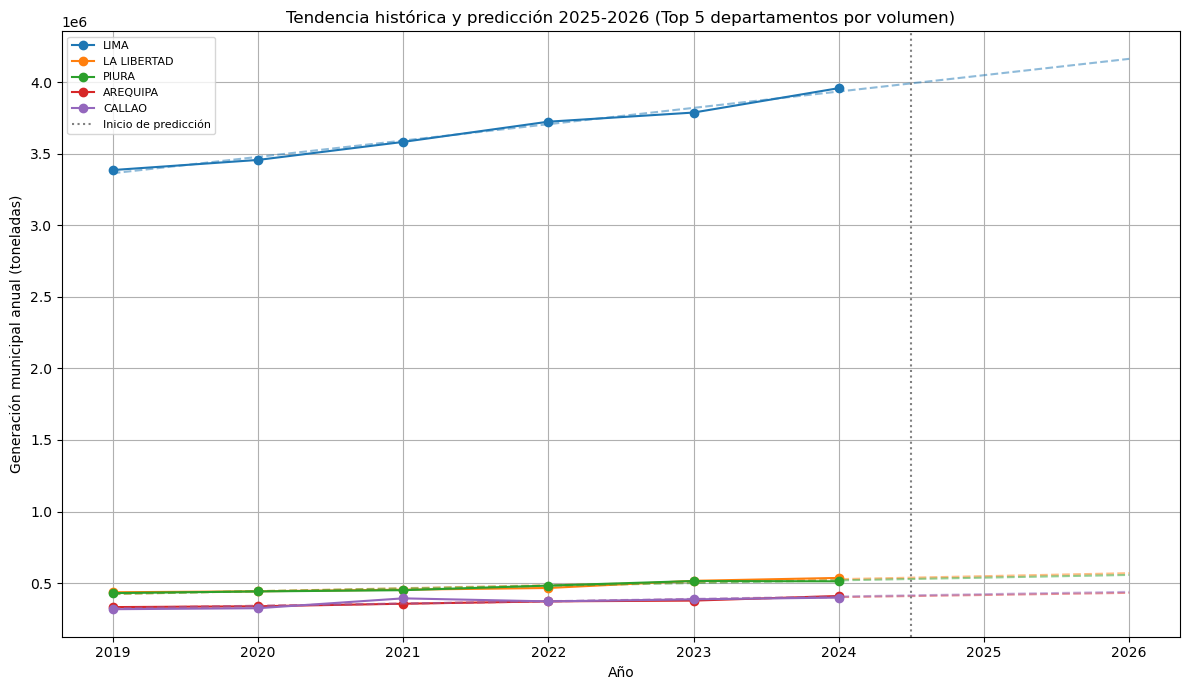

In [27]:
top5_deptos = df_resultados.head(5)['DEPARTAMENTO'].tolist()

plt.figure(figsize=(12, 7))
for depto in top5_deptos:
    info = predicciones_detalle[depto]
    X, y, modelo = info['X'], info['y'], info['modelo']
    anios_extendidos = np.arange(2019, 2027).reshape(-1, 1).astype(float)
    pred_extendida = modelo.predict(anios_extendidos)

    linea, = plt.plot(X.flatten(), y, marker='o', label=f'{depto}')
    plt.plot(anios_extendidos.flatten(), pred_extendida, linestyle='--', color=linea.get_color(), alpha=0.5)

plt.axvline(x=2024.5, color='gray', linestyle=':', label='Inicio de predicción')
plt.title('Tendencia histórica y predicción 2025-2026 (Top 5 departamentos por volumen)')
plt.xlabel('Año')
plt.ylabel('Generación municipal anual (toneladas)')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
df_resultados_mostrar = df_resultados.copy()
cols_redondear = ['R2_LOOCV', 'RMSE_LOOCV', 'MAE_LOOCV', 'GENERACION_2024',
                   'PREDICCION_2025', 'IC95_2025', 'PREDICCION_2026', 'IC95_2026']
df_resultados_mostrar[cols_redondear] = df_resultados_mostrar[cols_redondear].round(2)
df_resultados_mostrar.head(10)

,DEPARTAMENTO,R2_LOOCV,RMSE_LOOCV,MAE_LOOCV,GENERACION_2024,PREDICCION_2025,IC95_2025,PREDICCION_2026,IC95_2026
0,LIMA,0.96,37205.22,34343.52,3959659.17,4050247.45,103502.73,4164478.47,115483.17
1,LA LIBERTAD,0.76,18433.46,16348.53,535855.22,548073.93,55096.39,569039.49,61473.80
2,PIURA,0.86,12702.39,10779.42,511916.83,537755.26,39190.86,556673.10,43727.20
3,AREQUIPA,0.85,10251.39,8164.60,409691.95,416404.07,26688.04,431395.81,29777.18
4,CALLAO,0.53,22314.52,17475.35,398369.86,422175.78,78097.90,438503.11,87137.73
5,LAMBAYEQUE,-0.70,6257.29,4611.64,325152.90,319560.03,20043.02,318337.65,22363.00
6,JUNIN,0.62,6666.00,5555.78,303386.67,304180.95,18089.45,310046.54,20183.30
7,ICA,0.84,8386.27,6954.07,295282.24,307608.71,26154.15,319619.96,29181.49
8,ANCASH,0.63,5073.98,4376.15,264038.63,264786.49,14237.33,269322.83,15885.31
9,CUSCO,-0.16,8346.38,6422.24,254782.47,250503.17,22099.25,254095.22,24657.23


## 5. Implementación del Agente Inteligente (Arquitectura Orientada a Objetos)

Esta sección reestructura el pipeline desarrollado en las secciones anteriores
utilizando programación orientada a objetos. Se aplica el patron de diseño facade.

La clase AgenteResiduos tiene una interfaz simple
(percibir, procesar, clasificar, predecir) que oculta la complejidad
interna de las distintas etapas del análisis. Esta arquitectura es consistente
con la definición de agente inteligente presentada
en el Marco Teórico (Russell & Norvig, 2020).

In [ ]:
from agente_residuos import AgenteResiduos

agente = AgenteResiduos(
    ruta_csv="data/dataset_generacion_anual_de_residuos_solidos_domiciliarios_y_municipales.csv",
    separar_outliers=True
)

df_agente = agente.percibir()
print(f"Dataset cargado: {df_agente.shape[0]} registros, {df_agente.shape[1]} columnas")

agente.procesar()
print(f"Distritos para K-Means: {len(agente.gestor_datos.df_normal)}")
print(f"Distritos tratados como outliers: {len(agente.gestor_datos.df_outliers)}")

df_clasificado_agente = agente.clasificar()
print("\nDistribución de criticidad:")
print(df_clasificado_agente["CRITICIDAD"].value_counts())

df_predicciones_agente = agente.predecir()
print("\nTop 5 departamentos:")
df_predicciones_agente.head(5)[["DEPARTAMENTO", "GENERACION_MUN_TANIO_2024", "PREDICCION_2025", "PREDICCION_2026"]]

Dataset cargado: 11310 registros, 18 columnas
Distritos para K-Means: 9430
Distritos tratados como outliers: 1880

Distribución de criticidad:
CRITICIDAD
Baja     6549
Alta     3212
Media    1549
Name: count, dtype: int64

Top 5 departamentos:


,DEPARTAMENTO,GENERACION_MUN_TANIO_2024,PREDICCION_2025,PREDICCION_2026
0,LIMA,3959659.17,4.050247e+06,4.164478e+06
1,LA LIBERTAD,535855.22,5.480739e+05,5.690395e+05
2,PIURA,511916.83,5.377553e+05,5.566731e+05
3,AREQUIPA,409691.95,4.164041e+05,4.313958e+05
4,CALLAO,398369.86,4.221758e+05,4.385031e+05
